# Project 1: Cardiovascular Disease Prediction

This notebook implements a complete Machine Learning pipeline to predict the presence of cardiovascular disease in patients based on various health indicators. The dataset contains 70,000 patient records with clinical measurements like age, height, weight, gender, blood pressure, cholesterol, glucose, and lifestyle attributes.

### Objectives
1. **Data Pre-processing**: Load the data, clean anomalies/outliers, handle features (convert age from days to years), split the dataset, and perform feature scaling.
2. **Exploratory Data Analysis (EDA) & Visualizations**: Draw distribution and relationship plots to derive clinical insights.
3. **Correlation Matrix**: Analyze the relationships and multicollinearity among patient features.
4. **Classifier Evaluation**: Implement, train, and compare accuracy levels of **Support Vector Machines (SVM)**, **K-Nearest Neighbors (KNN)**, **Decision Trees (DT)**, **Logistic Regression (LR)**, and **Random Forest (RF)**.
5. **Best Model Selection**: Select and evaluate the best classifier using detailed metrics (precision, recall, f1-score, and confusion matrix).

## 1. Imports and Library Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries successfully imported!")

Matplotlib is building the font cache; this may take a moment.


Libraries successfully imported!


## 2. Loading the Dataset

In [2]:
# Load dataset from local directory (delimiter is ';')
df = pd.read_csv('cardio_train (1).csv', sep=';')

# Display basic shape and info
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Dataset Information:")
df.info()

print("\nMissing values count per column:")
print(df.isnull().sum())

print("\nFirst 5 rows of the dataset:")
df.head()

Dataset shape: 70000 rows, 13 columns

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Missing values count per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
choleste

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 3. Data Pre-processing & Outlier Handling

By analyzing the statistics of the raw data, we can see outliers that violate physiological limits:
- `height`: Minimum of 55 cm and maximum of 250 cm are biologically unrealistic for this adult cohort.
- `weight`: Minimum of 10 kg is unrealistic.
- `ap_hi` (systolic blood pressure): Ranges from -150 to 16020 mmHg. Normal range is between 80 and 220.
- `ap_lo` (diastolic blood pressure): Ranges from -70 to 11000 mmHg. Normal range is between 40 and 130.
- Systolic blood pressure must always be strictly greater than diastolic blood pressure (`ap_hi > ap_lo`).

We will filter out these anomalies and also convert `age` from days to years.

In [3]:
# Age in days is converted to years for cleaner interpretation
df_clean = df.copy()
df_clean['age_years'] = df_clean['age'] / 365.25

print(f"Original row count: {len(df)}")

# Filter out clinical and biological anomalies
df_clean = df_clean[
    (df_clean['height'] >= 130) & (df_clean['height'] <= 210) &
    (df_clean['weight'] >= 40) & (df_clean['weight'] <= 160) &
    (df_clean['ap_hi'] >= 80) & (df_clean['ap_hi'] <= 220) &
    (df_clean['ap_lo'] >= 40) & (df_clean['ap_lo'] <= 130) &
    (df_clean['ap_hi'] > df_clean['ap_lo'])
]

print(f"Cleaned row count: {len(df_clean)}")
print(f"Retained {len(df_clean) / len(df) * 100:.2f}% of data records after cleaning.")

# Drop raw identifier columns that don't contribute to modeling
df_model = df_clean.drop(columns=['id', 'age'])

print("\nSummary Statistics of Cleaned Dataset:")
df_model.describe()

Original row count: 70000
Cleaned row count: 68472
Retained 97.82% of data records after cleaning.

Summary Statistics of Cleaned Dataset:


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,68472.000000,68472.000000,68472.000000,68472.000000,68472.000000,68472.000000,68472.000000,68472.000000,68472.000000,68472.000000,68472.000000,68472.000000
mean,1.348595,164.442517,74.086597,126.653479,81.291404,1.364748,1.225640,0.087963,0.053306,0.803321,0.494669,53.292296
std,0.476529,7.835980,14.107785,16.595617,9.364712,0.678973,0.571505,0.283243,0.224646,0.397490,0.499975,6.756203
min,1.000000,130.000000,40.000000,80.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.563313
25%,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.344969
50%,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.938398
75%,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.381930
max,2.000000,207.000000,160.000000,220.000000,130.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.922656


## 4. Exploratory Data Analysis & Visualizations

We draw plots to understand relationships between predictors and target variables, and to check class distributions.

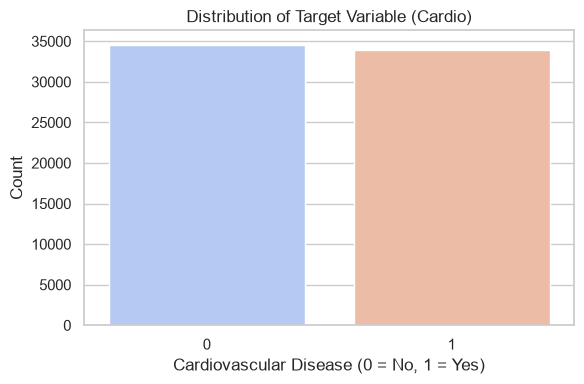

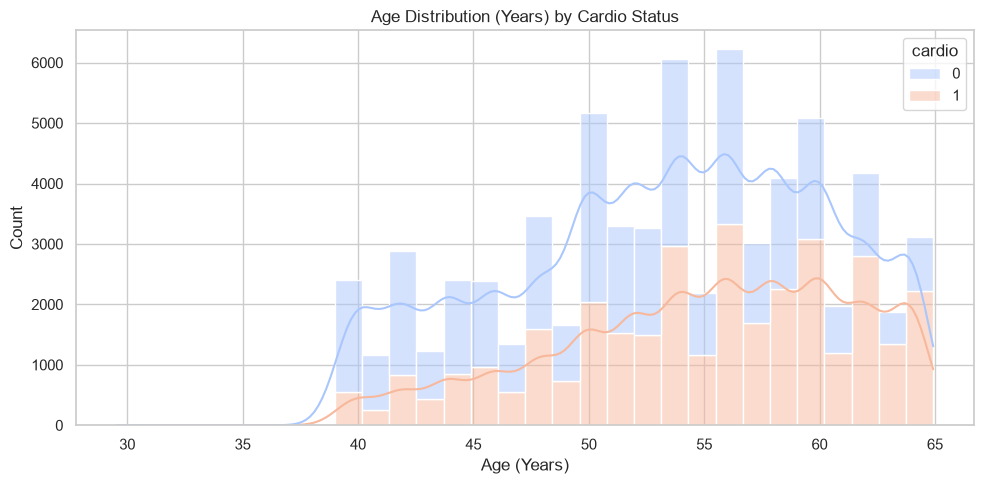

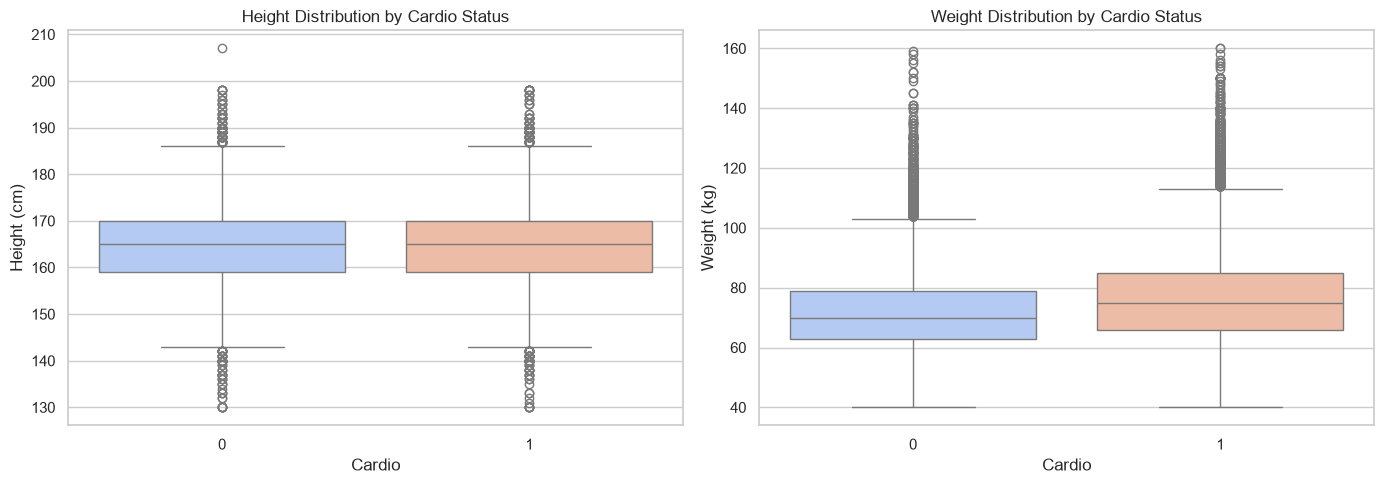

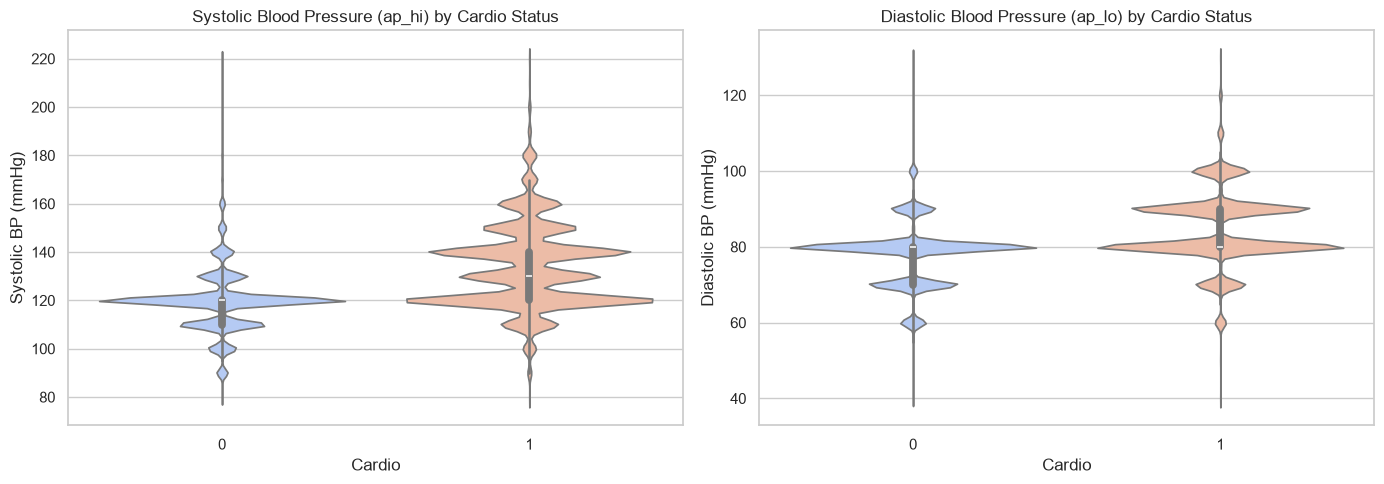

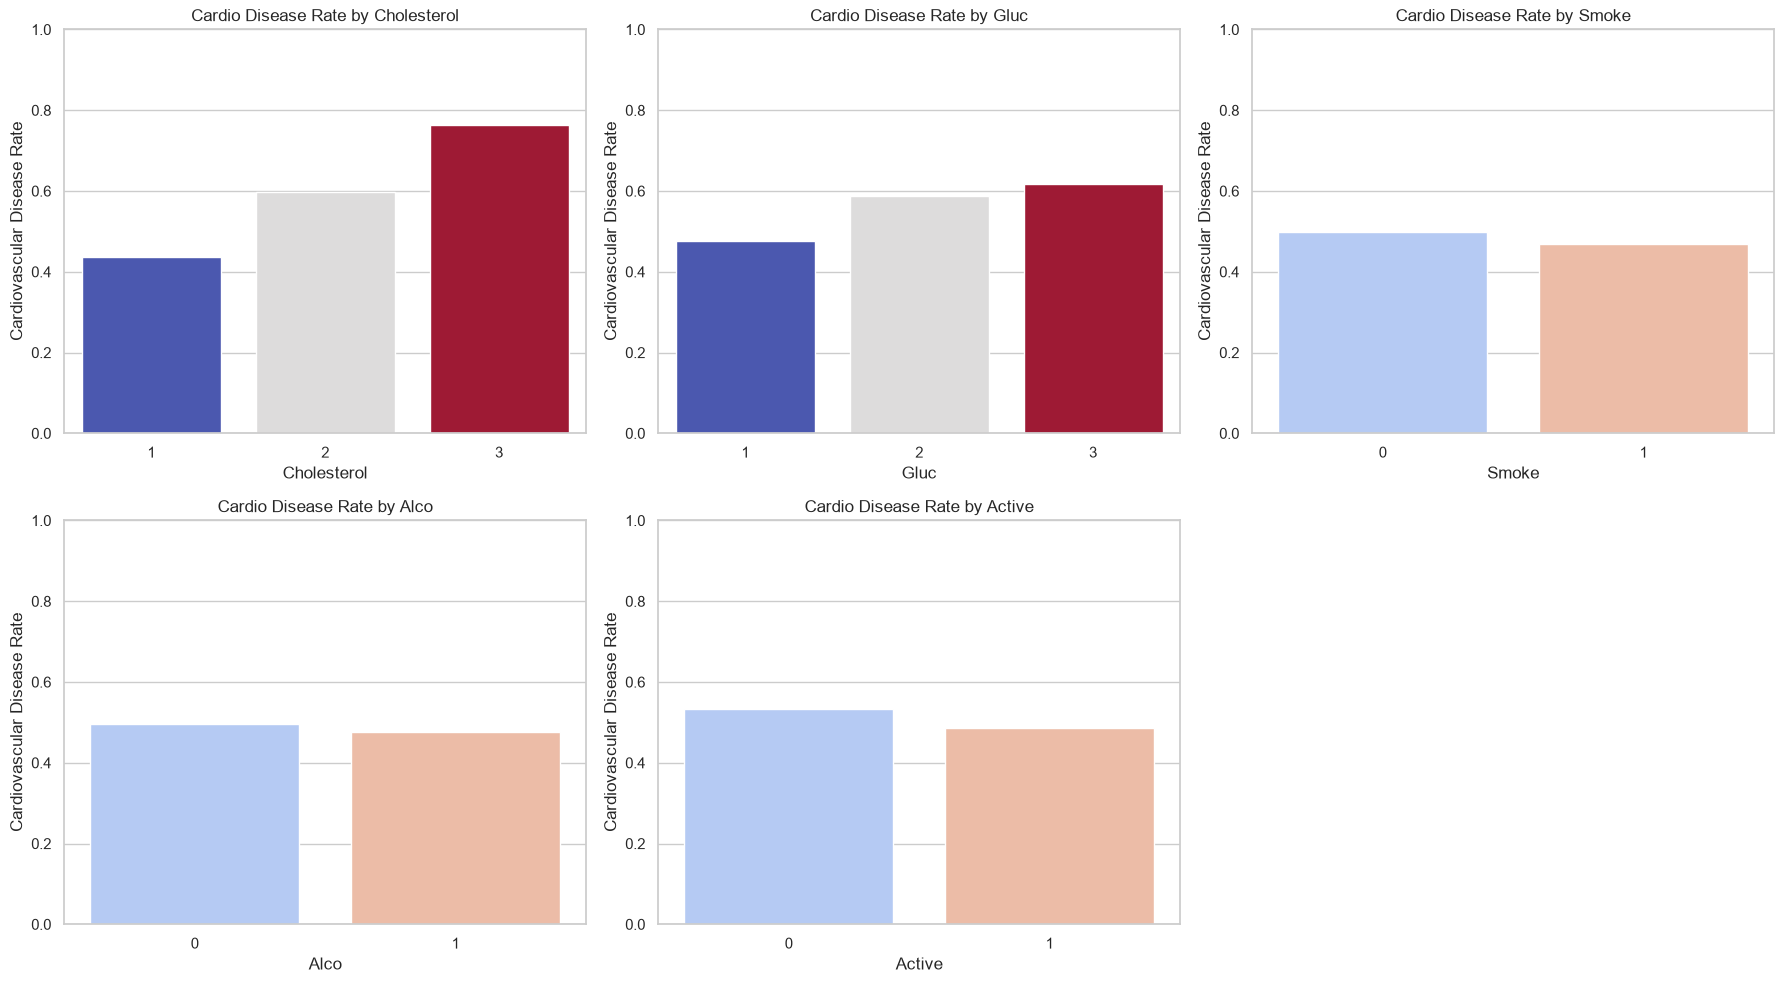

In [4]:
# 1. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_model, x='cardio', hue='cardio', palette='coolwarm', legend=False)
plt.title('Distribution of Target Variable (Cardio)')
plt.xlabel('Cardiovascular Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2. Age Distribution by Disease Status
plt.figure(figsize=(10, 5))
sns.histplot(data=df_model, x='age_years', hue='cardio', kde=True, multiple='stack', palette='coolwarm', bins=30)
plt.title('Age Distribution (Years) by Cardio Status')
plt.xlabel('Age (Years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Physical Attributes Box Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_model, x='cardio', y='height', hue='cardio', palette='coolwarm', ax=axes[0], legend=False)
axes[0].set_title('Height Distribution by Cardio Status')
axes[0].set_xlabel('Cardio')
axes[0].set_ylabel('Height (cm)')

sns.boxplot(data=df_model, x='cardio', y='weight', hue='cardio', palette='coolwarm', ax=axes[1], legend=False)
axes[1].set_title('Weight Distribution by Cardio Status')
axes[1].set_xlabel('Cardio')
axes[1].set_ylabel('Weight (kg)')
plt.tight_layout()
plt.show()

# 4. Blood Pressure Violin Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df_model, x='cardio', y='ap_hi', hue='cardio', palette='coolwarm', ax=axes[0], legend=False)
axes[0].set_title('Systolic Blood Pressure (ap_hi) by Cardio Status')
axes[0].set_xlabel('Cardio')
axes[0].set_ylabel('Systolic BP (mmHg)')

sns.violinplot(data=df_model, x='cardio', y='ap_lo', hue='cardio', palette='coolwarm', ax=axes[1], legend=False)
axes[1].set_title('Diastolic Blood Pressure (ap_lo) by Cardio Status')
axes[1].set_xlabel('Cardio')
axes[1].set_ylabel('Diastolic BP (mmHg)')
plt.tight_layout()
plt.show()

# 5. Categorical Risk Factors Analysis
cat_cols = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.barplot(data=df_model, x=col, y='cardio', palette='coolwarm', errorbar=None, ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Cardio Disease Rate by {col.capitalize()}')
    axes[i].set_ylabel('Cardiovascular Disease Rate')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylim(0, 1)
    
# Hide the unused 6th subplot
axes[5].axis('off')
plt.tight_layout()
plt.show()

## 5. Feature Correlation Matrix

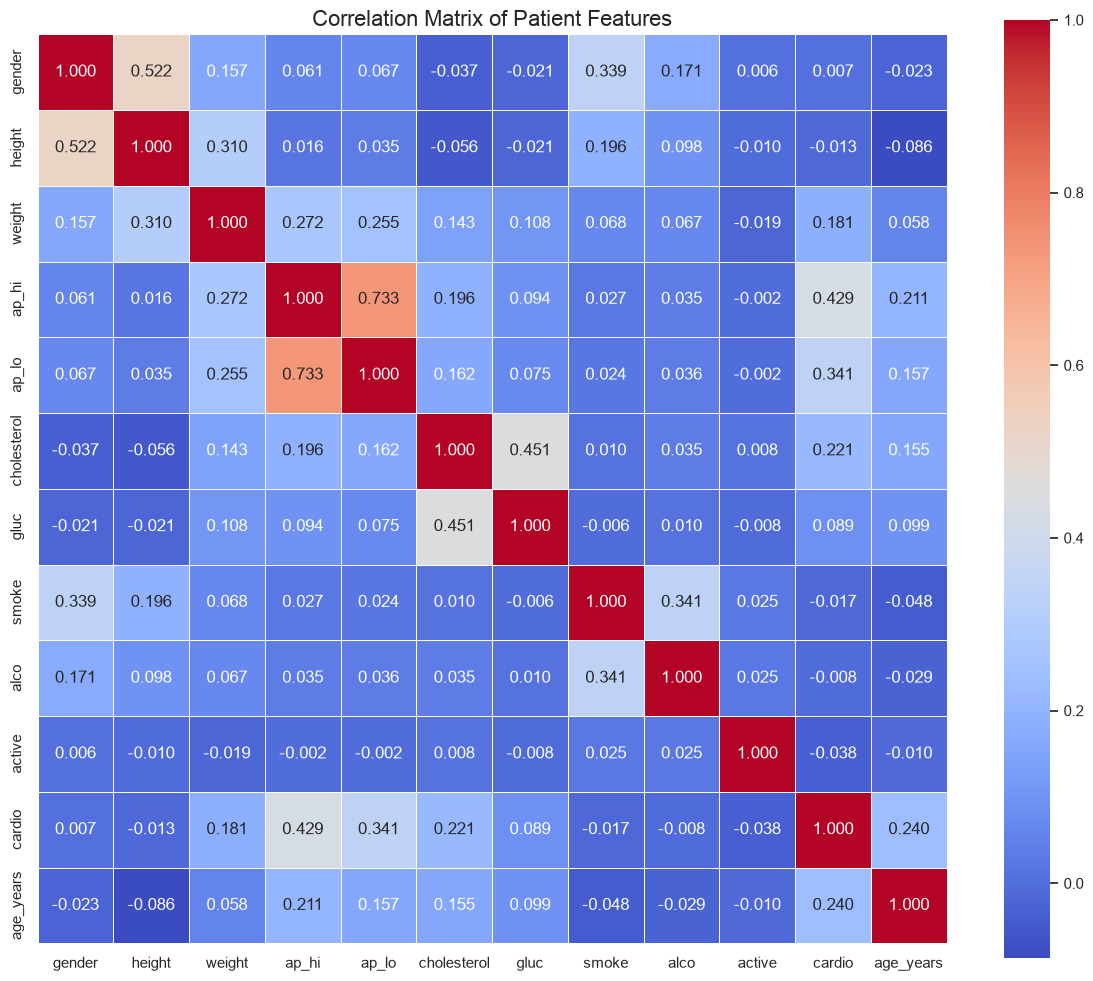

In [5]:
plt.figure(figsize=(12, 10))
# Compute the Pearson correlation matrix
corr_matrix = df_model.corr()

# Generate heat map
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Patient Features', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Machine Learning Classifiers Training & Evaluation

We will split the cleaned dataset into training (80%) and testing (20%) sets. Since SVM, KNN, and Logistic Regression are highly sensitive to feature scaling, we will standardize features using `StandardScaler` fitted on the training split.

In [6]:
# Define features X and target y
X = df_model.drop(columns=['cardio'])
y = df_model['cardio']

# Split train and test (stratified to ensure target distribution is preserved)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=9),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42)
}

results = {}

# Train and evaluate each classifier
for name, clf in classifiers.items():
    print(f"Training {name}... ", end="")
    t_start = time.time()
    clf.fit(X_train_scaled, y_train)
    t_end = time.time()
    
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    t_duration = t_end - t_start
    
    results[name] = {
        'Accuracy': acc,
        'Training Time (s)': t_duration,
        'Report': classification_report(y_test, y_pred, output_dict=True),
        'Model': clf
    }
    print(f"Done! Accuracy: {acc:.4%}, Duration: {t_duration:.2f}s")

Training Logistic Regression... Done! Accuracy: 72.9244%, Duration: 0.06s
Training K-Nearest Neighbors... 

Done! Accuracy: 71.1428%, Duration: 0.01s
Training Decision Tree... Done! Accuracy: 73.0705%, Duration: 0.05s
Training Random Forest... 

Done! Accuracy: 73.6546%, Duration: 1.70s
Training Support Vector Machine... 

Done! Accuracy: 73.3991%, Duration: 30.56s


## 7. Model Performance Comparison

Model Comparison Summary:


,Accuracy (%),Training Time (s),Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
Logistic Regression,72.924425,0.058555,0.758516,0.664009,0.708123
K-Nearest Neighbors,71.142753,0.014655,0.716610,0.689105,0.702589
Decision Tree,73.070464,0.051508,0.759328,0.666962,0.710154
Random Forest,73.654618,1.700514,0.766948,0.671391,0.715995
Support Vector Machine,73.399051,30.558241,0.764756,0.667552,0.712856


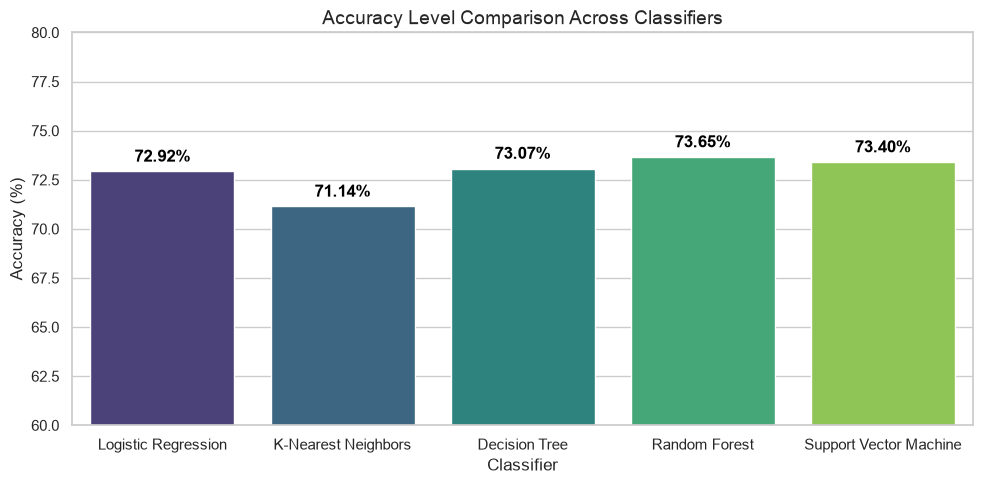

In [7]:
# Compile comparison table
comparison_df = pd.DataFrame({
    name: {
        'Accuracy (%)': info['Accuracy'] * 100,
        'Training Time (s)': info['Training Time (s)'],
        'Precision (Class 1)': info['Report']['1.0' if '1.0' in info['Report'] else '1']['precision'],
        'Recall (Class 1)': info['Report']['1.0' if '1.0' in info['Report'] else '1']['recall'],
        'F1-Score (Class 1)': info['Report']['1.0' if '1.0' in info['Report'] else '1']['f1-score']
    } for name, info in results.items()
}).T

print("Model Comparison Summary:")
display(comparison_df.style.highlight_max(subset=['Accuracy (%)', 'F1-Score (Class 1)'], color='lightgreen'))

# Accuracy bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=comparison_df.index, y=comparison_df['Accuracy (%)'], palette='viridis', hue=comparison_df.index, legend=False)
plt.title('Accuracy Level Comparison Across Classifiers', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.xlabel('Classifier')
plt.ylim(60, 80)

for idx, row in enumerate(comparison_df.itertuples()):
    plt.text(idx, row._1 + 0.5, f"{row._1:.2f}%", color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Final Model Analysis

We identify the best classifier, render its Confusion Matrix, and examine the feature importances (or coefficients) to explain model decisions.

=== Best Machine Learning Model: Random Forest ===
Accuracy: 73.6546%
Training Time: 1.70 seconds



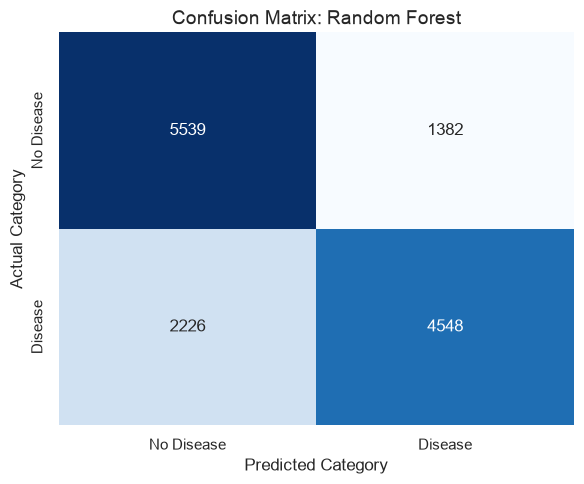

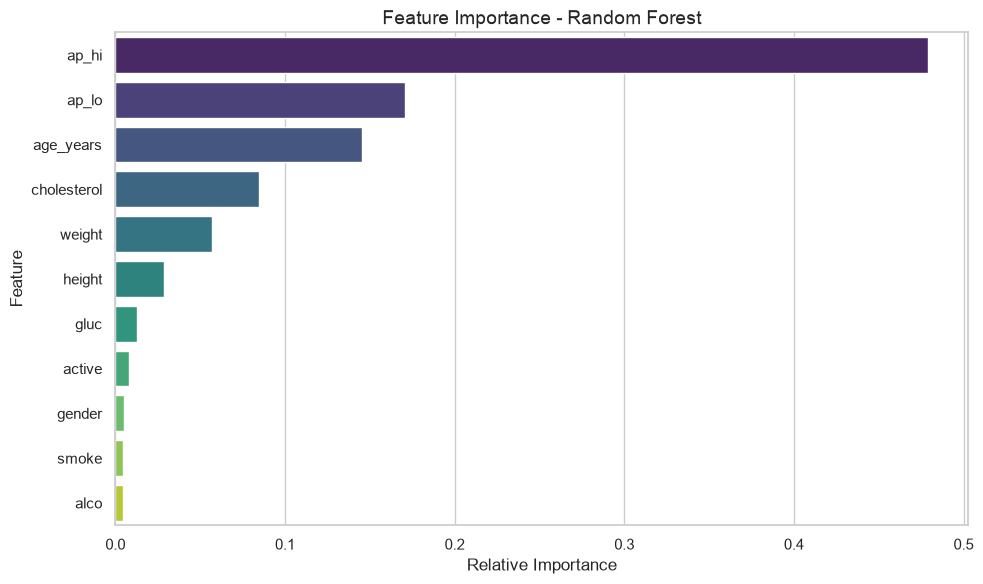

In [8]:
best_name = comparison_df['Accuracy (%)'].idxmax()
best_info = results[best_name]
best_model = best_info['Model']

print(f"=== Best Machine Learning Model: {best_name} ===")
print(f"Accuracy: {best_info['Accuracy']:.4%}")
print(f"Training Time: {best_info['Training Time (s)']:.2f} seconds\n")

# Generate predictions and plot confusion matrix
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix: {best_name}', fontsize=14)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.show()

# Feature Importance / Coefficient Analysis
if best_name in ['Random Forest', 'Decision Tree']:
    importances = best_model.feature_importances_
    feat_imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
    plt.title(f'Feature Importance - {best_name}', fontsize=14)
    plt.xlabel('Relative Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
elif best_name == 'Logistic Regression':
    coefs = best_model.coef_[0]
    feat_coef = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': coefs,
        'Absolute Coefficient': abs(coefs)
    }).sort_values(by='Absolute Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_coef, x='Coefficient', y='Feature', palette='coolwarm', hue='Feature', legend=False)
    plt.axvline(x=0, color='grey', linestyle='--')
    plt.title(f'Feature Coefficients - {best_name}', fontsize=14)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Feature importance/coefficients are not directly accessible for {best_name}. SVC model successfully trained and finalized!")